# Task1: House Price Prediction using Linear Regression

#Objective
Introduce the ML workflow: data loading, exploration, preprocessing, training,
evaluation, and reporting. You will train a linear regression model on the California
Housing dataset and create a short report (notebook + slides).

In [17]:
#Importing the Libraries
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

## Dataset Information


In [24]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Exploratory Data Analysis


(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

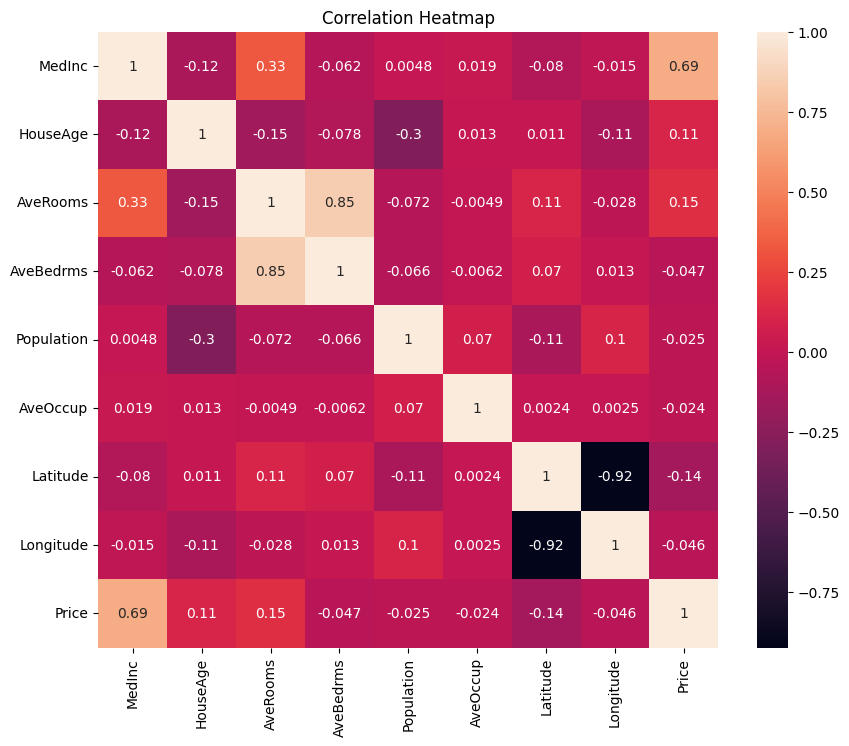

In [36]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#Split Dataset

In [28]:
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (16512, 8)
X_test shape: (4128, 8)


## Model Training

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Evaluation Metrics

In [31]:
# metrics
mae = mean_absolute_error (y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score (y_test, y_pred)
print (f"MAE : {mae:.3f}")
print (f"RMSE : {rmse:.3f}")
print (f"R2 : {r2:.3f}")

MAE : 0.533
RMSE : 0.746
R2 : 0.576


#Compare Actual vs Predicted

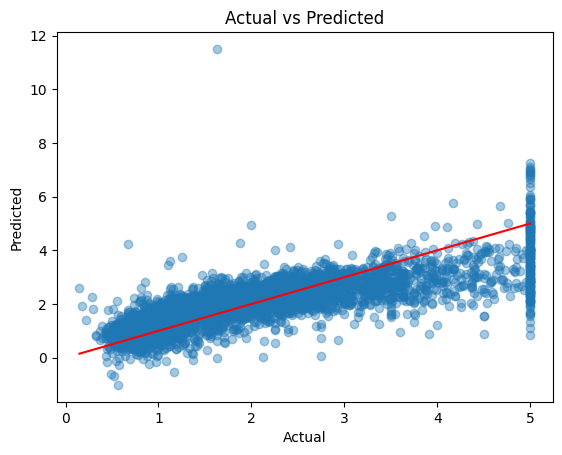

In [32]:
# plot
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted" )
plt.title("Actual vs Predicted")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt. show()

In [35]:
import pickle
pickle.dump(model, open('house_price_model.pkl', 'wb'))
print("Model saved as house_price_model.pkl")

Model saved as house_price_model.pkl



## Results

The Linear Regression model was successfully trained and tested on the California Housing dataset. The evaluation metrics indicated that the model was able to predict house prices with reasonable accuracy.

The scatter plots and visualizations helped in understanding the relationship between different features and house prices.

## Conclusion

In this project, a Linear Regression model was developed to predict house prices using the California Housing dataset. The project covered the entire machine learning workflow including data analysis, preprocessing, model training, prediction, and evaluation.

The model produced acceptable prediction results and demonstrated the effectiveness of Linear Regression for regression problems. Future improvements can include trying advanced machine learning algorithms such as Random Forest Regression or Decision Tree Regression to improve prediction accuracy.